In [1]:
import os
import re
import sys
import importlib
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import regression_functions as rf
from matplotlib.backends.backend_pdf import PdfPages
from figure_formatting import setup_figure, save_figure
from regression_functions import run_model_comparison as run_model
importlib.reload(rf)

<module 'regression_functions' from '/mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/code/regression_functions.py'>

### Read in the data 

From `covbat_harmonization_ses.Rmd` followed by `abcd_prep_harmonized_dfs`

In [2]:
# ROOT_DIR = Path("/Users/bmacedo/Desktop/final_WM")
ROOT_DIR = Path("/mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome")
RESULTS_DIR = ROOT_DIR / "output_data" / "results"

# main results data
dfA_macro = pd.read_csv(RESULTS_DIR / "dfA_macro_12_10.csv")
dfB_macro = pd.read_csv(RESULTS_DIR / "dfB_macro_12_10.csv")

dfA_NODDI = pd.read_csv(RESULTS_DIR / "dfA_NODDI_12_10.csv")
dfB_NODDI = pd.read_csv(RESULTS_DIR / "dfB_NODDI_12_10.csv")

dfA_macro_plus_NODDI = pd.read_csv(RESULTS_DIR / "dfA_macro_plus_NODDI_12_10.csv")
dfB_macro_plus_NODDI = pd.read_csv(RESULTS_DIR / "dfB_macro_plus_NODDI_12_10.csv")

dfA_DKI = pd.read_csv(RESULTS_DIR / "dfA_DKI_12_10.csv")
dfB_DKI = pd.read_csv(RESULTS_DIR / "dfB_DKI_12_10.csv")

dfA_macro_plus_DKI = pd.read_csv(RESULTS_DIR / "dfA_macro_plus_DKI_12_10.csv")
dfB_macro_plus_DKI = pd.read_csv(RESULTS_DIR / "dfB_macro_plus_DKI_12_10.csv")


# sensitivity data
dfA_macro_sens = pd.read_csv(RESULTS_DIR / "dfA_macro_sens_11_30.csv")
dfB_macro_sens = pd.read_csv(RESULTS_DIR / "dfB_macro_sens_11_30.csv")

dfA_NODDI_sens = pd.read_csv(RESULTS_DIR / "dfA_NODDI_sens_11_30.csv")
dfB_NODDI_sens = pd.read_csv(RESULTS_DIR / "dfB_NODDI_sens_11_30.csv")

dfA_macro_plus_NODDI_sens = pd.read_csv(RESULTS_DIR / "dfA_macro_plus_NODDI_sens_11_30.csv")
dfB_macro_plus_NODDI_sens = pd.read_csv(RESULTS_DIR / "dfB_macro_plus_NODDI_sens_11_30.csv")

dfA_DKI_sens = pd.read_csv(RESULTS_DIR / "dfA_DKI_sens_11_30.csv")
dfB_DKI_sens = pd.read_csv(RESULTS_DIR / "dfB_DKI_sens_11_30.csv")

dfA_macro_plus_DKI_sens = pd.read_csv(RESULTS_DIR / "dfA_macro_plus_DKI_sens_11_30.csv")
dfB_macro_plus_DKI_sens = pd.read_csv(RESULTS_DIR / "dfB_macro_plus_DKI_sens_11_30.csv")

In [3]:
tracts = sorted(set(
    "_".join(c.split("_")[1:3])
    for c in dfA_macro_plus_NODDI.columns
    if c.startswith("bundle_")))

print(len(tracts))

62


In [4]:
# --- cleanup helper: drop mean columns, strip _median from remaining columns ---
def clean_bundle_columns(df):
    df = df.copy()

    bundle_cols_mean = [c for c in df.columns if c.startswith("bundle_") and "_mean" in c]
    df = df.drop(columns=bundle_cols_mean, errors="ignore")

    df = df.rename(columns=lambda c: c[:-len("_median")]
        if c.startswith("bundle_") and c.endswith("_median")
        else c)

    return df

dfs_to_clean = ["dfA_macro", "dfB_macro", "dfA_NODDI", "dfB_NODDI", "dfA_macro_plus_NODDI", "dfB_macro_plus_NODDI",
                "dfA_DKI", "dfB_DKI", "dfA_macro_plus_DKI", "dfB_macro_plus_DKI"]

for df_name in dfs_to_clean:
    globals()[df_name] = clean_bundle_columns(globals()[df_name])

# --- helper to extract metric name from cleaned columns ---
def extract_metric_name(col):
    if not col.startswith("bundle_"):
        return None

    parts = col[len("bundle_"):].split("_")
    if len(parts) < 3: return None

    # first two parts are the bundle name, rest is the metric
    return "_".join(parts[2:])


# --- metric summaries after cleaning ---
noddi_macro_metrics = sorted({m for c in dfA_macro_plus_NODDI.columns if (m := extract_metric_name(c)) is not None})
dki_macro_metrics = sorted({m for c in dfA_macro_plus_DKI.columns if (m := extract_metric_name(c)) is not None})

print(f"NODDI metrics count: {len(noddi_macro_metrics)}")
print(f"DKI metrics count: {len(dki_macro_metrics)}")

print("\nNODDI metrics:")
print(noddi_macro_metrics)

print("\nDKI metrics:")
print(dki_macro_metrics)

NODDI metrics count: 20
DKI metrics count: 26

NODDI metrics:
['1st_quarter_volume_mm3', '2nd_and_3rd_quarter_volume_mm3', '4th_quarter_volume_mm3', 'NODDI_icvf', 'NODDI_isovf', 'NODDI_od', 'area_of_end_region_1_mm2', 'area_of_end_region_2_mm2', 'curl', 'elongation', 'irregularity', 'radius_of_end_region_1_mm', 'radius_of_end_region_2_mm', 'span_mm', 'total_area_of_end_regions_mm2', 'total_radius_of_end_regions_mm', 'total_surface_area_mm2', 'total_volume_mm3', 'volume_of_end_branches_1', 'volume_of_end_branches_2']

DKI metrics:
['1st_quarter_volume_mm3', '2nd_and_3rd_quarter_volume_mm3', '4th_quarter_volume_mm3', 'DKI_ad', 'DKI_ak', 'DKI_fa', 'DKI_kfa', 'DKI_md', 'DKI_mk', 'DKI_mkt', 'DKI_rd', 'DKI_rk', 'area_of_end_region_1_mm2', 'area_of_end_region_2_mm2', 'curl', 'elongation', 'irregularity', 'radius_of_end_region_1_mm', 'radius_of_end_region_2_mm', 'span_mm', 'total_area_of_end_regions_mm2', 'total_radius_of_end_regions_mm', 'total_surface_area_mm2', 'total_volume_mm3', 'volume_o

### Mutlivariate Global Ridge Regression

NODDI as primary model, DKI as sensitivity analysis

Includes sensitivity analyses with brain volume correction (eTIV)

In [5]:
metrics = noddi_macro_metrics

In [25]:
SUPPFIG_BASE_DIR = ROOT_DIR / "output_data" / "results" / "supplemental_figures"
SUPPFIG8_DIR = SUPPFIG_BASE_DIR / "suppfig8"
SUPPFIG9_DIR = SUPPFIG_BASE_DIR / "suppfig9"
MODEL_DIR = ROOT_DIR / "output_data" / "model_outputs"

for d in [SUPPFIG8_DIR, SUPPFIG9_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

color_disc = {"NODDI": "#5D3FD3", "Macrostructure": "#0033A0", "Macrostructure and NODDI": "#C69214"}
color_repl = {"NODDI": "#B8A6F9", "Macrostructure": "#7BA6E6", "Macrostructure and NODDI": "#E9CB7F"}

figure_configs = [
    {"tag": "suppfig8_main_ses",
     "save_dir": SUPPFIG8_DIR,
     "model_output_dir": MODEL_DIR,
     "targets": ["General_SES"],
     "scenarios_top": [("NODDI", dfA_NODDI, dfB_NODDI),
                       ("Macrostructure", dfA_macro, dfB_macro),
                       ("Macrostructure and NODDI", dfA_macro_plus_NODDI, dfB_macro_plus_NODDI)],
     "df_map_A": {"NODDI": dfA_NODDI, "Macrostructure": dfA_macro, "Macrostructure and NODDI": dfA_macro_plus_NODDI},
     "df_map_B": {"NODDI": dfB_NODDI, "Macrostructure": dfB_macro, "Macrostructure and NODDI": dfB_macro_plus_NODDI},
     "model_type": "ridge",
     "n_components": 17},

    {"tag": "suppfig9_income_edu_sensitivity",
     "save_dir": SUPPFIG9_DIR,
     "model_output_dir": MODEL_DIR,
     "targets": ["income", "parental_education", "le_l_adi__addr1__national_prcnt"],
     "scenarios_top": [("NODDI", dfA_NODDI_sens, dfB_NODDI_sens),
                       ("Macrostructure", dfA_macro_sens, dfB_macro_sens),
                       ("Macrostructure and NODDI", dfA_macro_plus_NODDI_sens, dfB_macro_plus_NODDI_sens)],
     "df_map_A": {"NODDI": dfA_NODDI_sens, "Macrostructure": dfA_macro_sens, "Macrostructure and NODDI": dfA_macro_plus_NODDI_sens},
     "df_map_B": {"NODDI": dfB_NODDI_sens, "Macrostructure": dfB_macro_sens, "Macrostructure and NODDI": dfB_macro_plus_NODDI_sens},
     "model_type": "ridge",
     "n_components": 17}
]

In [26]:
def run_one_figure(cfg, target):
    scenarios_top = cfg["scenarios_top"]
    df_map_A, df_map_B = cfg["df_map_A"], cfg["df_map_B"]
    model_type, n_comp, tag = cfg["model_type"], cfg["n_components"], cfg["tag"]
    save_dir = cfg["save_dir"]
    model_output_dir = cfg.get("model_output_dir", save_dir)

    c_disc, c_repl = color_disc, color_repl

    results = {}
    for name, df_A, df_B in scenarios_top:
        conf = ["age", "sex", "t1post_dwi_contrast"]
        features = [c for c in df_A.columns if c.startswith("bundle_")]
        if model_type == "ridge":
            perf, _ = rf.run_model_comparison(features_subset=features, df_A=df_A, df_B=df_B,
                                              target=target, output_dir=model_output_dir,
                                              confounds=conf, model_type="ridge")
        else:
            perf, _ = rf.run_pls_model_exact(df_A, df_B, features_subset=features, target=target,
                                             confounds=conf, max_components=20, cv_tuning=True, fixed_n=n_comp)
        results[name] = perf

    fig = plt.figure(figsize=(12, 4.5))
    gs = fig.add_gridspec(1, 3, wspace=0.3)
    titles = [n for n, _, _ in scenarios_top]
    scatter_axes = [fig.add_subplot(gs[0, i]) for i in range(3)]

    scatter_axes[1].sharex(scatter_axes[0]); scatter_axes[2].sharex(scatter_axes[0])
    scatter_axes[1].sharey(scatter_axes[0]); scatter_axes[2].sharey(scatter_axes[0])

    for ax, (name, title) in zip(scatter_axes, zip([n for n, _, _ in scenarios_top], titles)):
        perf = results[name]
        y_true_1, y_pred_1 = perf["y_true_B"], perf["y_pred_B"]
        y_true_2, y_pred_2 = perf["y_true_A"], perf["y_pred_A"]

        ax.scatter(y_true_2, y_pred_2, color=c_repl[name], alpha=0.25, s=14, marker="^", label=f"replication (r={perf['r_B']:.2f})")
        ax.scatter(y_true_1, y_pred_1, color=c_disc[name], alpha=0.25, s=10, marker="o", label=f"discovery (r={perf['r_A']:.2f})")

        min_val = min(y_true_1.min(), y_pred_1.min(), y_true_2.min(), y_pred_2.min())
        max_val = max(y_true_1.max(), y_pred_1.max(), y_true_2.max(), y_pred_2.max())

        s1, i1 = np.polyfit(y_true_1, y_pred_1, 1)
        s2, i2 = np.polyfit(y_true_2, y_pred_2, 1)

        ax.plot([min_val, max_val], [s1 * min_val + i1, s1 * max_val + i1], color=c_disc[name], lw=2.2)
        ax.plot([min_val, max_val], [s2 * min_val + i2, s2 * max_val + i2], color=c_repl[name], lw=2.2)

        ax.set_facecolor("white")
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlim(min_val, max_val)
        ax.set_ylim(min_val, max_val)
        ax.set_title(title, fontsize=14)
        ax.set_xlabel("")
        ax.set_ylabel("")

        handles, labels = ax.get_legend_handles_labels()
        ax.legend([handles[1], handles[0]], [labels[1], labels[0]], frameon=False, fontsize=11, loc="lower right")
        sns.despine(ax=ax, top=True, right=True)

    fig.supxlabel(f"Actual {target.replace('_', ' ').title()} (z)", fontsize=16)
    fig.supylabel(f"Predicted {target.replace('_', ' ').title()} (z)", fontsize=16)

    plt.subplots_adjust(left=0.07, right=0.98, top=0.88, bottom=0.12)
    scatter_png = save_dir / f"{tag}_{target}_Scatters.png"
    scatter_svg = save_dir / f"{tag}_{target}_Scatters.svg"
    plt.savefig(scatter_png, dpi=600, bbox_inches="tight", facecolor="white")
    plt.savefig(scatter_svg, bbox_inches="tight", facecolor="white")
    print(f"[SAVE] → {scatter_png}")
    print(f"[SAVE] → {scatter_svg}")
    plt.show()

    fig = plt.figure(figsize=(12, 4.0))
    ax_lolli = fig.add_subplot(111)

    feature_sets = [n for n, _, _ in scenarios_top]
    disc_no, repl_no, disc_yes, repl_yes = [], [], [], []

    for fs in feature_sets:
        df_A = df_map_A[fs]
        df_B = df_map_B[fs]

        conf_no = ["age", "sex", "t1post_dwi_contrast"]
        conf_yes = ["age", "sex", "t1post_dwi_contrast", "eTIV"]
        feats = [c for c in df_A.columns if c.startswith("bundle_")]

        perf_no, _ = rf.run_model_comparison(features_subset=feats, df_A=df_A, df_B=df_B,
                                             target=target, output_dir=model_output_dir,
                                             confounds=conf_no, model_type="ridge")
        perf_yes, _ = rf.run_model_comparison(features_subset=feats, df_A=df_A, df_B=df_B,
                                              target=target, output_dir=model_output_dir,
                                              confounds=conf_yes, model_type="ridge")

        disc_no.append(perf_no["r_A"]); repl_no.append(perf_no["r_B"])
        disc_yes.append(perf_yes["r_A"]); repl_yes.append(perf_yes["r_B"])

    lolli_df = pd.DataFrame({"Feature Set": feature_sets,
                             "Discovery r (no eTBV)": disc_no,
                             "Replication r (no eTBV)": repl_no,
                             "Discovery r (+eTBV)": disc_yes,
                             "Replication r (+eTBV)": repl_yes})

    print(f"\n=== LOLLIPOP VALUES ({target.replace('_', ' ').title()} Prediction) ===")
    print(lolli_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

    x = np.arange(len(feature_sets))
    width, marker_noTIV, marker_yesTIV = 0.20, 200, 260
    stem_lw, bottom_offset = 3, 0.12

    for i, fs in enumerate(feature_sets):
        dcol = c_disc[fs]; rcol = c_repl[fs]

        ax_lolli.vlines(x[i]-1.5*width, bottom_offset, disc_no[i], color=dcol, lw=stem_lw)
        ax_lolli.scatter(x[i]-1.5*width, disc_no[i], color=dcol, marker="o", s=marker_noTIV)

        ax_lolli.vlines(x[i]-0.5*width, bottom_offset, repl_no[i], color=rcol, lw=stem_lw)
        ax_lolli.scatter(x[i]-0.5*width, repl_no[i], color=rcol, marker="o", s=marker_noTIV)

        ax_lolli.vlines(x[i]+0.5*width, bottom_offset, disc_yes[i], color=dcol, lw=stem_lw)
        ax_lolli.scatter(x[i]+0.5*width, disc_yes[i], color=dcol, marker="s", s=marker_yesTIV)

        ax_lolli.vlines(x[i]+1.5*width, bottom_offset, repl_yes[i], color=rcol, lw=stem_lw)
        ax_lolli.scatter(x[i]+1.5*width, repl_yes[i], color=rcol, marker="s", s=marker_yesTIV)

    ax_lolli.set_xticks(x)
    ax_lolli.set_xticklabels(feature_sets, fontsize=13)
    ax_lolli.set_xlabel("Feature Set", fontsize=16)
    ax_lolli.set_ylabel("Correlation (r)", fontsize=16)
    ax_lolli.set_ylim(bottom_offset, max(disc_no + repl_no + disc_yes + repl_yes) + 0.05)

    legend_handles = [plt.Line2D([0], [0], color="black", marker="o", lw=0, markersize=10),
                      plt.Line2D([0], [0], color="black", marker="s", lw=0, markersize=10)]

    ax_lolli.legend(legend_handles, ["without eTBV correction", "with eTBV correction"], frameon=False, fontsize=12, ncol=2)
    ax_lolli.spines["top"].set_visible(False)
    ax_lolli.spines["right"].set_visible(False)
    ax_lolli.spines["bottom"].set_color("black")
    ax_lolli.tick_params(axis="y", length=0)

    plt.subplots_adjust(left=0.09, right=0.98, top=0.92, bottom=0.20)
    lolli_png = save_dir / f"{tag}_{target}_Lollipop.png"
    lolli_svg = save_dir / f"{tag}_{target}_Lollipop.svg"
    plt.savefig(lolli_png, dpi=600, bbox_inches="tight", facecolor="white")
    plt.savefig(lolli_svg, bbox_inches="tight", facecolor="white")
    print(f"[SAVE] → {lolli_png}")
    print(f"[SAVE] → {lolli_svg}")
    plt.show()

    return results


RUNNING: suppfig8_main_ses

### TARGET = GENERAL_SES ###
[SAVE] → /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig8/suppfig8_main_ses_General_SES_Scatters.png
[SAVE] → /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig8/suppfig8_main_ses_General_SES_Scatters.svg


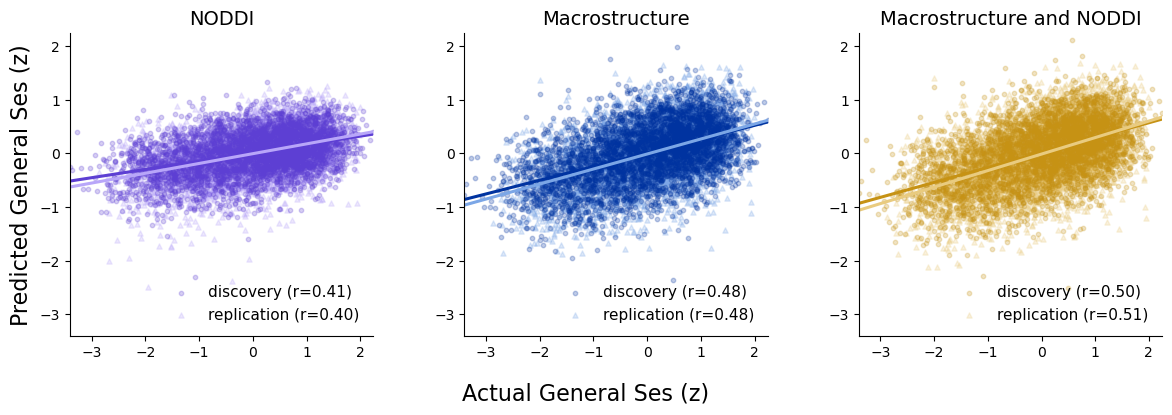


=== LOLLIPOP VALUES (General Ses Prediction) ===
             Feature Set  Discovery r (no eTBV)  Replication r (no eTBV)  Discovery r (+eTBV)  Replication r (+eTBV)
                   NODDI                  0.410                    0.401                0.363                  0.352
          Macrostructure                  0.481                    0.484                0.420                  0.418
Macrostructure and NODDI                  0.504                    0.508                0.447                  0.445
[SAVE] → /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig8/suppfig8_main_ses_General_SES_Lollipop.png
[SAVE] → /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig8/suppfig8_main_ses_General_SES_Lollipop.svg


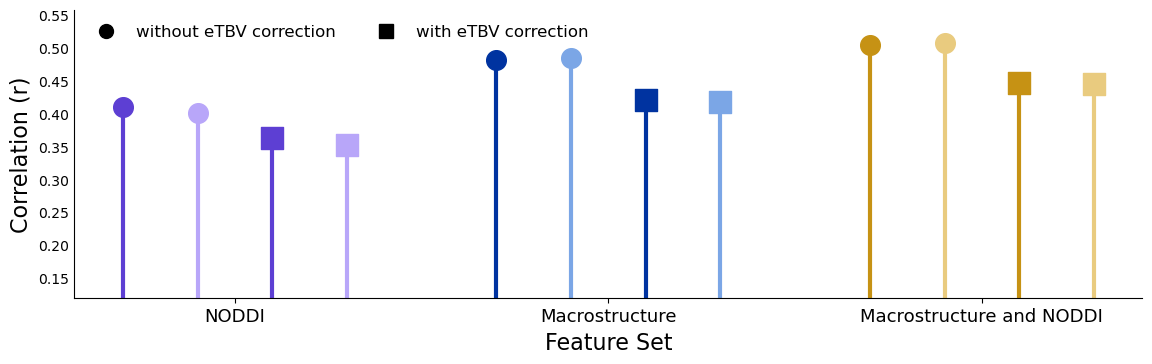


RUNNING: suppfig9_income_edu_sensitivity

### TARGET = INCOME ###
[SAVE] → /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/suppfig9_income_edu_sensitivity_income_Scatters.png
[SAVE] → /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/suppfig9_income_edu_sensitivity_income_Scatters.svg


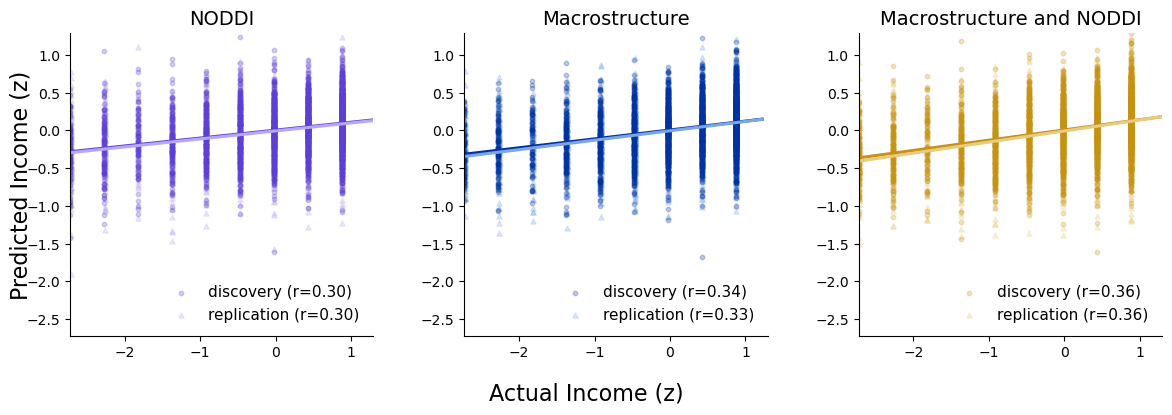


=== LOLLIPOP VALUES (Income Prediction) ===
             Feature Set  Discovery r (no eTBV)  Replication r (no eTBV)  Discovery r (+eTBV)  Replication r (+eTBV)
                   NODDI                  0.302                    0.296                0.254                  0.254
          Macrostructure                  0.337                    0.335                0.282                  0.265
Macrostructure and NODDI                  0.361                    0.358                0.307                  0.296
[SAVE] → /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/suppfig9_income_edu_sensitivity_income_Lollipop.png
[SAVE] → /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/suppfig9_income_edu_sensitivity_income_Lollipop.svg


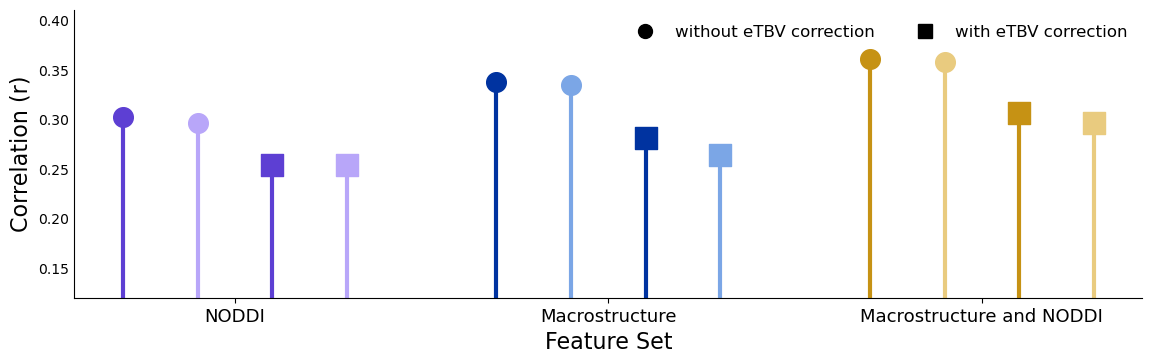


### TARGET = PARENTAL_EDUCATION ###
[SAVE] → /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/suppfig9_income_edu_sensitivity_parental_education_Scatters.png
[SAVE] → /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/suppfig9_income_edu_sensitivity_parental_education_Scatters.svg


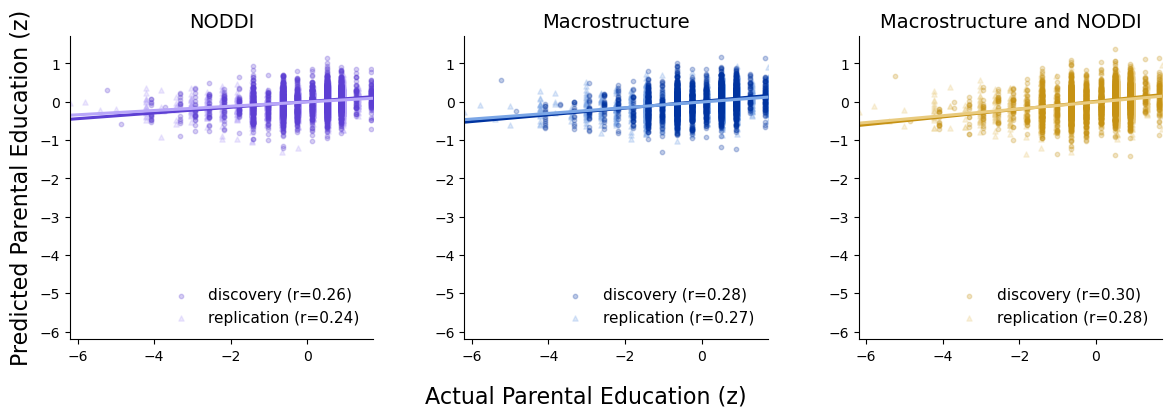


=== LOLLIPOP VALUES (Parental Education Prediction) ===
             Feature Set  Discovery r (no eTBV)  Replication r (no eTBV)  Discovery r (+eTBV)  Replication r (+eTBV)
                   NODDI                  0.258                    0.241                0.232                  0.208
          Macrostructure                  0.278                    0.272                0.217                  0.219
Macrostructure and NODDI                  0.303                    0.284                0.246                  0.240
[SAVE] → /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/suppfig9_income_edu_sensitivity_parental_education_Lollipop.png
[SAVE] → /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/suppfig9_income_edu_sensitivity_parental_education_Lollipop.svg


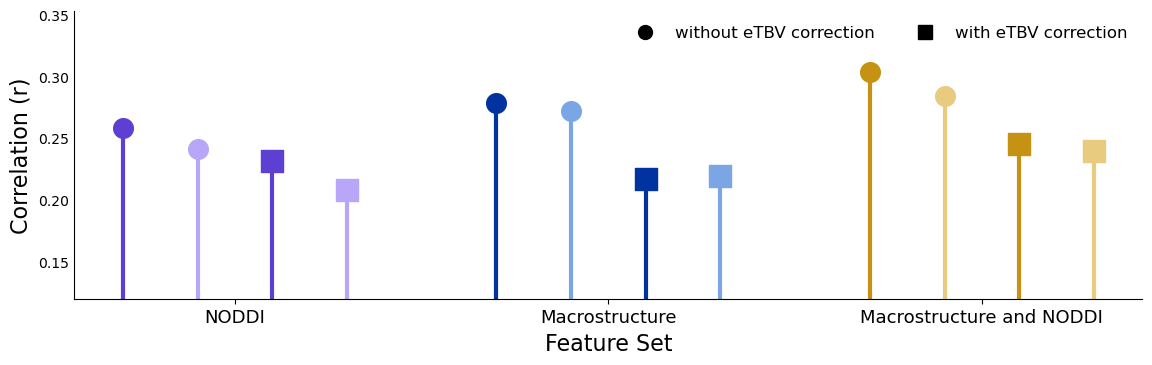


### TARGET = LE_L_ADI__ADDR1__NATIONAL_PRCNT ###
[SAVE] → /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/suppfig9_income_edu_sensitivity_le_l_adi__addr1__national_prcnt_Scatters.png
[SAVE] → /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/suppfig9_income_edu_sensitivity_le_l_adi__addr1__national_prcnt_Scatters.svg


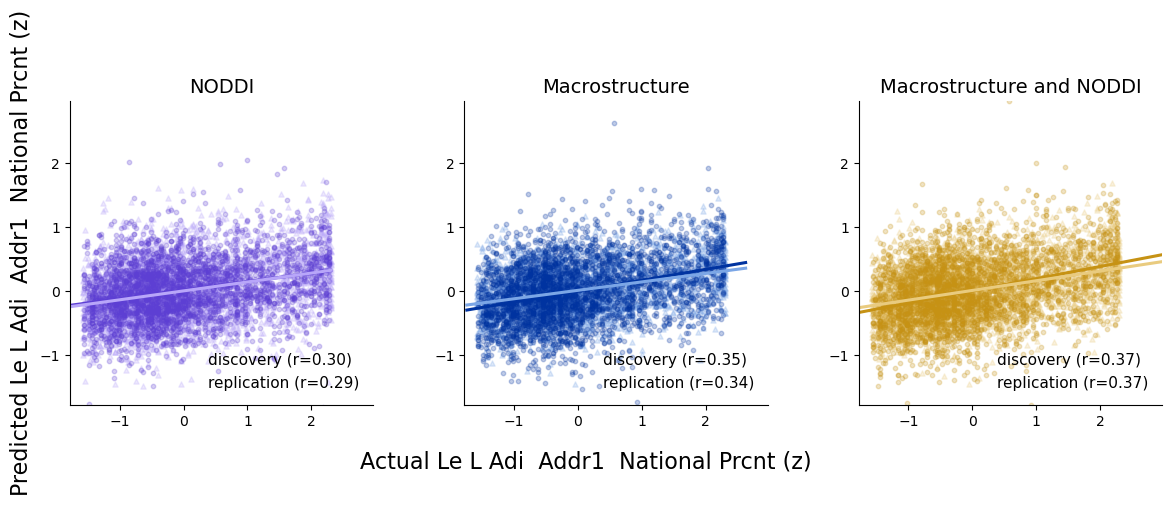


=== LOLLIPOP VALUES (Le L Adi  Addr1  National Prcnt Prediction) ===
             Feature Set  Discovery r (no eTBV)  Replication r (no eTBV)  Discovery r (+eTBV)  Replication r (+eTBV)
                   NODDI                  0.296                    0.290                0.265                  0.259
          Macrostructure                  0.351                    0.345                0.331                  0.319
Macrostructure and NODDI                  0.369                    0.366                0.346                  0.339
[SAVE] → /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/suppfig9_income_edu_sensitivity_le_l_adi__addr1__national_prcnt_Lollipop.png
[SAVE] → /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/suppfig9_income_edu_sensitivity_le_l_adi__addr1__national_prcnt_Lollipop.svg


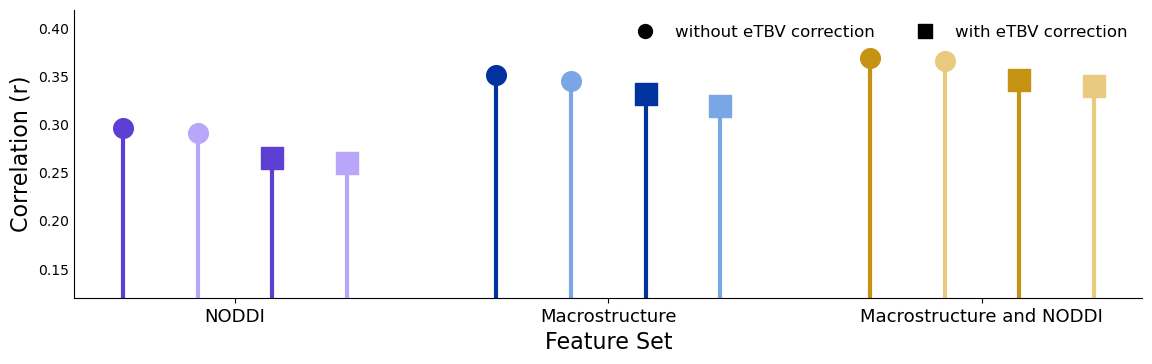

In [8]:
all_results = {}

for cfg in figure_configs:
    print(f"\n==============================")
    print(f"RUNNING: {cfg['tag']}")
    print(f"==============================")

    for target in cfg["targets"]:
        print(f"\n### TARGET = {target.upper()} ###")
        all_results[(cfg["tag"], target)] = run_one_figure(cfg, target)

In [20]:
from pathlib import Path
import itertools
import numpy as np
import pandas as pd

SUPPFIG9_DIR = SUPPFIG_BASE_DIR / "suppfig9"
MODEL_DIR = ROOT_DIR / "output_data" / "model_outputs"

for d in [SUPPFIG9_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

scenarios_main = [
    ("NODDI", dfA_NODDI, dfB_NODDI),
    ("Macrostructure", dfA_macro, dfB_macro),
    ("Macrostructure and NODDI", dfA_macro_plus_NODDI, dfB_macro_plus_NODDI),
]

scenarios_sens = [
    ("NODDI", dfA_NODDI_sens, dfB_NODDI_sens),
    ("Macrostructure", dfA_macro_sens, dfB_macro_sens),
    ("Macrostructure and NODDI", dfA_macro_plus_NODDI_sens, dfB_macro_plus_NODDI_sens),
]

# General_SES = your "exposome" model here
targets = [
    "General_SES",
    "income",
    "parental_education",
    "le_l_adi__addr1__national_prcnt",
]

target_to_scenarios = {
    "General_SES": scenarios_main,
    "income": scenarios_sens,
    "parental_education": scenarios_sens,
    "le_l_adi__addr1__national_prcnt": scenarios_sens,
}

target_label_map = {
    "General_SES": "General Exposome",
    "income": "Income",
    "parental_education": "Parental education",
    "le_l_adi__addr1__national_prcnt": "ADI",
}

conf = ["age", "sex", "t1post_dwi_contrast"]


def run_target_models(target_name):
    scenarios = target_to_scenarios[target_name]
    results = {}

    for scen_name, df_A, df_B in scenarios:
        features = [c for c in df_A.columns if c.startswith("bundle_")]

        perf, haufe_df = rf.run_model_comparison(
            features_subset=features,
            df_A=df_A,
            df_B=df_B,
            target=target_name,
            output_dir=MODEL_DIR,
            confounds=conf,
            model_type="ridge",
        )

        results[scen_name] = {
            "performance": perf,
            "haufe": haufe_df.copy(),
        }

    return results


all_results = {t: run_target_models(t) for t in targets}

# -----------------------------
# Pull out named Haufe dictionaries
# -----------------------------
haufe_expo = {
    fs: all_results["General_SES"][fs]["haufe"].copy()
    for fs in all_results["General_SES"]
}
haufe_income = {
    fs: all_results["income"][fs]["haufe"].copy()
    for fs in all_results["income"]
}
haufe_pedu = {
    fs: all_results["parental_education"][fs]["haufe"].copy()
    for fs in all_results["parental_education"]
}
haufe_adi = {
    fs: all_results["le_l_adi__addr1__national_prcnt"][fs]["haufe"].copy()
    for fs in all_results["le_l_adi__addr1__national_prcnt"]
}

# optional container if you want all Haufe maps together
haufe_by_target = {
    "General_SES": haufe_expo,
    "income": haufe_income,
    "parental_education": haufe_pedu,
    "le_l_adi__addr1__national_prcnt": haufe_adi,
}

# -----------------------------
# Performance summary
# -----------------------------
rows = []
for t in targets:
    for scen_name, res in all_results[t].items():
        perf = res["performance"]
        rows.append({
            "target": t,
            "target_label": target_label_map[t],
            "feature_set": scen_name,
            "R2_discovery_A": perf.get("r2_A", np.nan),
            "R2_replication_B": perf.get("r2_B", np.nan),
            "r_discovery_A": perf.get("r_A", np.nan),
            "r_replication_B": perf.get("r_B", np.nan),
        })

r2_df = pd.DataFrame(rows)

pivot_rA = r2_df.pivot(index="feature_set", columns="target", values="r_discovery_A")
pivot_rB = r2_df.pivot(index="feature_set", columns="target", values="r_replication_B")

inc_rows = []
for fs in pivot_rA.index:
    inc_rows.append({
        "feature_set": fs,
        "IncR_General_minus_income_A": pivot_rA.loc[fs, "General_SES"] - pivot_rA.loc[fs, "income"],
        "IncR_General_minus_income_B": pivot_rB.loc[fs, "General_SES"] - pivot_rB.loc[fs, "income"],
        "IncR_General_minus_parentEdu_A": pivot_rA.loc[fs, "General_SES"] - pivot_rA.loc[fs, "parental_education"],
        "IncR_General_minus_parentEdu_B": pivot_rB.loc[fs, "General_SES"] - pivot_rB.loc[fs, "parental_education"],
        "IncR_General_minus_adi_A": pivot_rA.loc[fs, "General_SES"] - pivot_rA.loc[fs, "le_l_adi__addr1__national_prcnt"],
        "IncR_General_minus_adi_B": pivot_rB.loc[fs, "General_SES"] - pivot_rB.loc[fs, "le_l_adi__addr1__national_prcnt"],
    })

inc_df = pd.DataFrame(inc_rows)

print("\n=== partial r by target and feature set ===")
print(r2_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

print("\n=== Incremental partial r (General_SES minus baseline targets) ===")
print(inc_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

final_df = r2_df.merge(inc_df, on="feature_set", how="left")

# -----------------------------
# Long-format Haufe summary table
# -----------------------------
haufe_rows = []
for t in targets:
    for fs, res in all_results[t].items():
        hdf = res["haufe"].copy()
        hdf["target"] = t
        hdf["target_label"] = target_label_map[t]
        hdf["feature_set"] = fs
        haufe_rows.append(hdf)

haufe_long_df = pd.concat(haufe_rows, axis=0, ignore_index=True)

r2_path = SUPPFIG9_DIR / "target_comparison_r_values.csv"
inc_path = SUPPFIG9_DIR / "target_comparison_incremental_r.csv"
final_path = SUPPFIG9_DIR / "target_comparison_summary.csv"
haufe_long_path = SUPPFIG9_DIR / "target_comparison_haufe_long.csv"

r2_df.to_csv(r2_path, index=False)
inc_df.to_csv(inc_path, index=False)
final_df.to_csv(final_path, index=False)
haufe_long_df.to_csv(haufe_long_path, index=False)

print(f"[SAVE] -> {r2_path}")
print(f"[SAVE] -> {inc_path}")
print(f"[SAVE] -> {final_path}")
print(f"[SAVE] -> {haufe_long_path}")


=== partial r by target and feature set ===
                         target       target_label              feature_set  R2_discovery_A  R2_replication_B  r_discovery_A  r_replication_B
                    General_SES   General Exposome                    NODDI           0.166             0.160          0.410            0.401
                    General_SES   General Exposome           Macrostructure           0.221             0.231          0.481            0.484
                    General_SES   General Exposome Macrostructure and NODDI           0.242             0.255          0.504            0.508
                         income             Income                    NODDI           0.089             0.084          0.302            0.296
                         income             Income           Macrostructure           0.113             0.112          0.337            0.335
                         income             Income Macrostructure and NODDI           0.128            

In [22]:
def _corr(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    ok = np.isfinite(a) & np.isfinite(b)
    if ok.sum() < 3:
        return np.nan, np.nan
    r, p = pearsonr(a[ok], b[ok])
    return r, p


def _merge_haufe(df_x, df_y):
    d = df_x.merge(df_y, on="feature", suffixes=("_x", "_y"))
    need = [
        "haufe_weight_AtoB_x", "haufe_weight_AtoB_y",
        "haufe_weight_BtoA_x", "haufe_weight_BtoA_y",
    ]
    miss = [c for c in need if c not in d.columns]
    if miss:
        raise ValueError(f"Missing columns after merge: {miss}")
    return d


def plot_haufe_similarity_pair(
    haufe_dict_x,
    haufe_dict_y,
    label_x,
    label_y,
    fs="Macrostructure and NODDI",
    outpath=None,
    width_mm=180,
    height_mm=70,
    margins_mm=(24, 10, 16, 8),
):
    d = _merge_haufe(haufe_dict_x[fs], haufe_dict_y[fs])

    fig, axes = setup_figure(
        width_mm=width_mm,
        height_mm=height_mm,
        margins_mm=margins_mm,
        nrows=1,
        ncols=2,
        sharex=False,
        sharey=False,
        axes_linewidth=0.8,
        axes_aspect="auto",
        sans_list="Helvetica",
        base_pt=7,
        label_pt=7,
        title_pt=7,
    )

    ax1, ax2 = axes.ravel()

    def draw_panel(ax, x, y, title=None):
        x = np.asarray(x)
        y = np.asarray(y)
        r, p = _corr(x, y)

        ok = np.isfinite(x) & np.isfinite(y)
        if ok.sum() == 0:
            lim = 1
        else:
            lim = np.nanmax(np.abs(np.r_[x[ok], y[ok]]))
            lim = max(lim, 1e-6)

        ax.scatter(x, y, s=12, alpha=0.35)
        ax.axhline(0, lw=1)
        ax.axvline(0, lw=1)
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)

        if title is not None:
            ax.set_title(title)

        ax.text(
            0.03, 0.97,
            rf"$\it{{r}}$ = {r:.3f}" + "\n" + rf"$\it{{p}}$ = {p:.1e}",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=7,
        )

        ax.tick_params(axis="both", length=3, width=0.8, direction="out")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    draw_panel(ax1, d["haufe_weight_AtoB_x"], d["haufe_weight_AtoB_y"], "Discovery")
    draw_panel(ax2, d["haufe_weight_BtoA_x"], d["haufe_weight_BtoA_y"], "Replication")

    ax1.set_xlabel(f"Haufe weight ({label_x})")
    ax2.set_xlabel(f"Haufe weight ({label_x})")
    ax1.set_ylabel(f"Haufe weight ({label_y})")

    if outpath is not None:
        outpath = Path(outpath)
        outpath.parent.mkdir(parents=True, exist_ok=True)
        save_figure(fig, outpath, autofit=False)
        png_path = outpath.with_suffix(".png")
        fig.savefig(png_path, dpi=600, bbox_inches="tight")
        print(f"[SAVE] -> {outpath}")
        print(f"[SAVE] -> {png_path}")

    plt.show()
    return fig, d

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

[SAVE] -> /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/Haufe_NODDI_GeneralExposome_vs_Income.svg
[SAVE] -> /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/Haufe_NODDI_GeneralExposome_vs_Income.png


findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

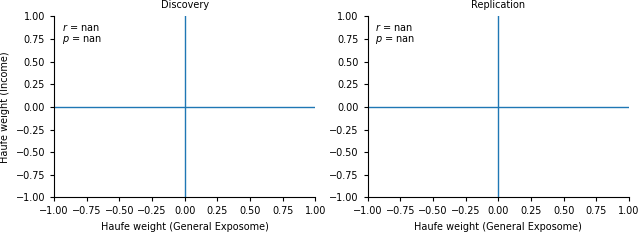

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

[SAVE] -> /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/Haufe_NODDI_GeneralExposome_vs_Parentaleducation.svg
[SAVE] -> /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/Haufe_NODDI_GeneralExposome_vs_Parentaleducation.png


findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

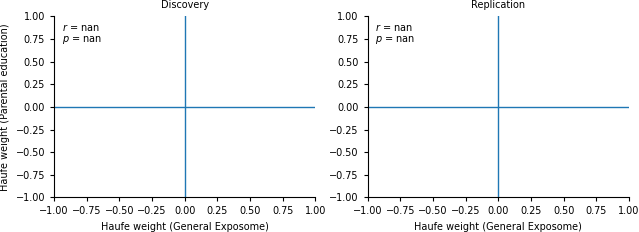

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

[SAVE] -> /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/Haufe_NODDI_GeneralExposome_vs_ADI.svg
[SAVE] -> /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/Haufe_NODDI_GeneralExposome_vs_ADI.png


findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

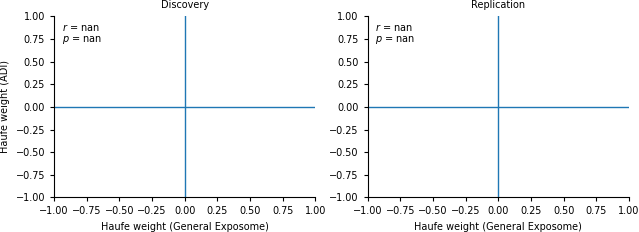

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

[SAVE] -> /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/Haufe_NODDI_Income_vs_Parentaleducation.svg
[SAVE] -> /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/Haufe_NODDI_Income_vs_Parentaleducation.png


findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

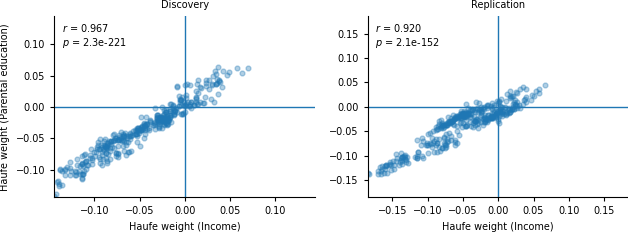

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

[SAVE] -> /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/Haufe_NODDI_Income_vs_ADI.svg
[SAVE] -> /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/Haufe_NODDI_Income_vs_ADI.png


findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

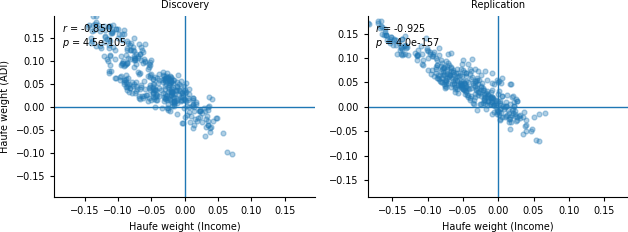

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

[SAVE] -> /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/Haufe_NODDI_Parentaleducation_vs_ADI.svg
[SAVE] -> /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/Haufe_NODDI_Parentaleducation_vs_ADI.png


findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

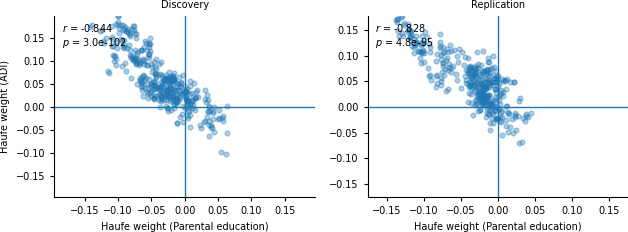

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

[SAVE] -> /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/Haufe_Macrostructure_GeneralExposome_vs_Income.svg
[SAVE] -> /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/Haufe_Macrostructure_GeneralExposome_vs_Income.png


findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica


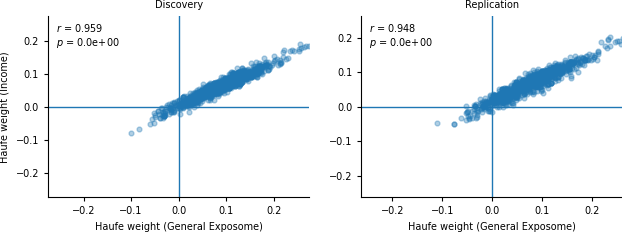

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

[SAVE] -> /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/Haufe_Macrostructure_GeneralExposome_vs_Parentaleducation.svg
[SAVE] -> /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/Haufe_Macrostructure_GeneralExposome_vs_Parentaleducation.png


findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

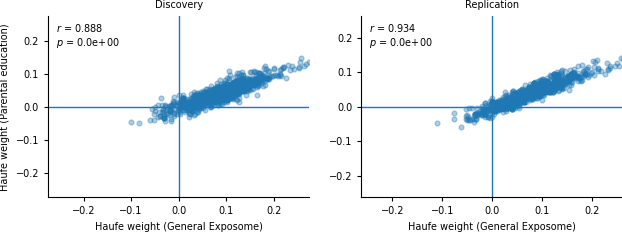

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

[SAVE] -> /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/Haufe_Macrostructure_GeneralExposome_vs_ADI.svg
[SAVE] -> /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/Haufe_Macrostructure_GeneralExposome_vs_ADI.png


findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

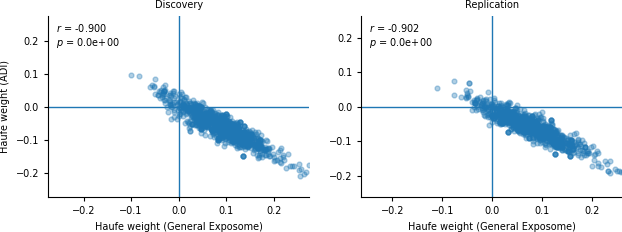

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

[SAVE] -> /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/Haufe_Macrostructure_Income_vs_Parentaleducation.svg
[SAVE] -> /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/Haufe_Macrostructure_Income_vs_Parentaleducation.png


findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

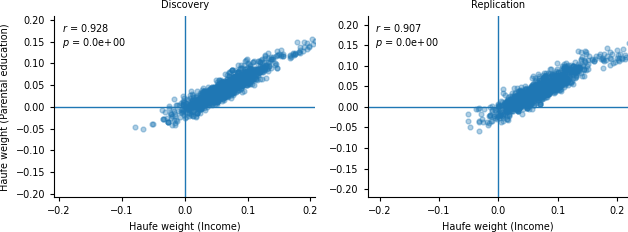

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

[SAVE] -> /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/Haufe_Macrostructure_Income_vs_ADI.svg
[SAVE] -> /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/Haufe_Macrostructure_Income_vs_ADI.png


findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

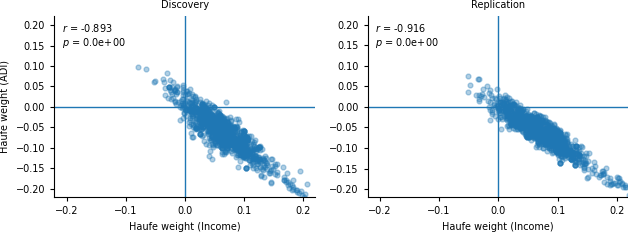

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

[SAVE] -> /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/Haufe_Macrostructure_Parentaleducation_vs_ADI.svg
[SAVE] -> /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/Haufe_Macrostructure_Parentaleducation_vs_ADI.png


findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

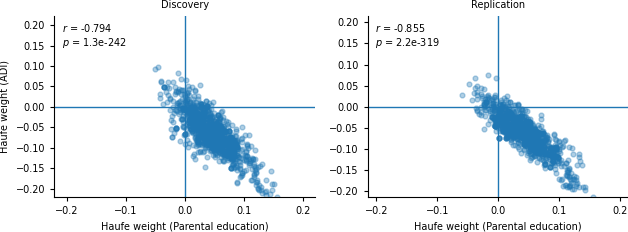

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

[SAVE] -> /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/Haufe_Macrostructure_and_NODDI_GeneralExposome_vs_Income.svg
[SAVE] -> /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/Haufe_Macrostructure_and_NODDI_GeneralExposome_vs_Income.png


findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica


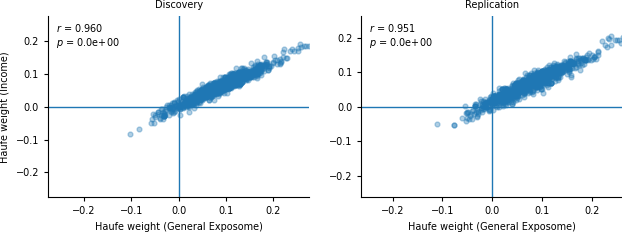

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

[SAVE] -> /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/Haufe_Macrostructure_and_NODDI_GeneralExposome_vs_Parentaleducation.svg
[SAVE] -> /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/Haufe_Macrostructure_and_NODDI_GeneralExposome_vs_Parentaleducation.png


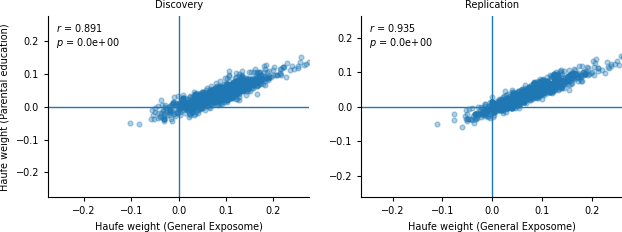

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

[SAVE] -> /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/Haufe_Macrostructure_and_NODDI_GeneralExposome_vs_ADI.svg
[SAVE] -> /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/Haufe_Macrostructure_and_NODDI_GeneralExposome_vs_ADI.png


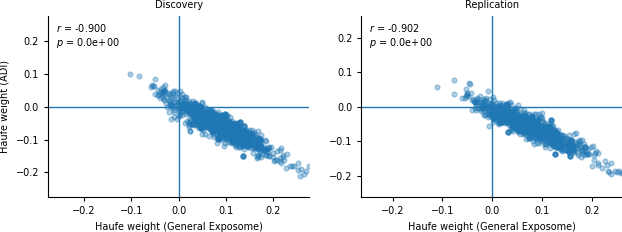

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

[SAVE] -> /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/Haufe_Macrostructure_and_NODDI_Income_vs_Parentaleducation.svg
[SAVE] -> /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/Haufe_Macrostructure_and_NODDI_Income_vs_Parentaleducation.png


findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica


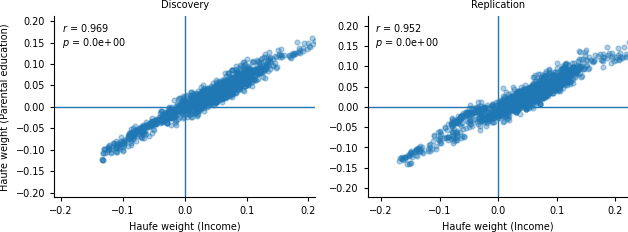

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

[SAVE] -> /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/Haufe_Macrostructure_and_NODDI_Income_vs_ADI.svg
[SAVE] -> /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/Haufe_Macrostructure_and_NODDI_Income_vs_ADI.png


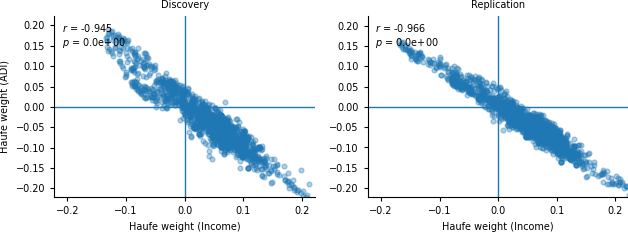

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

[SAVE] -> /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/Haufe_Macrostructure_and_NODDI_Parentaleducation_vs_ADI.svg
[SAVE] -> /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig9/Haufe_Macrostructure_and_NODDI_Parentaleducation_vs_ADI.png


findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica


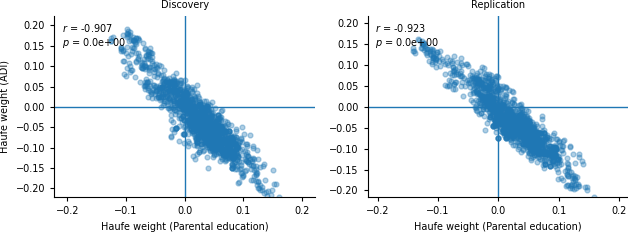

             feature_set           target_x           target_y  r_discovery  p_discovery  r_replication  p_replication  n_features
                   NODDI   General Exposome             Income          NaN          NaN            NaN            NaN           0
                   NODDI   General Exposome Parental education          NaN          NaN            NaN            NaN           0
                   NODDI   General Exposome                ADI          NaN          NaN            NaN            NaN           0
                   NODDI             Income Parental education       0.9668   2.318e-221         0.9198     2.103e-152         372
                   NODDI             Income                ADI      -0.8501   4.517e-105        -0.9246     4.031e-157         372
                   NODDI Parental education                ADI      -0.8442   3.016e-102        -0.8281      4.801e-95         372
          Macrostructure   General Exposome             Income       0.9586        

In [28]:
haufe_maps = {
    "General Exposome": haufe_expo,
    "Income": haufe_income,
    "Parental education": haufe_pedu,
    "ADI": haufe_adi,
}

feature_sets = [
    "NODDI",
    "Macrostructure",
    "Macrostructure and NODDI",
]

pairwise_corr_rows = []

for fs in feature_sets:
    for (label_x, dict_x), (label_y, dict_y) in itertools.combinations(haufe_maps.items(), 2):
        fig, d = plot_haufe_similarity_pair(
            dict_x,
            dict_y,
            label_x=label_x,
            label_y=label_y,
            fs=fs,
            outpath=SUPPFIG9_DIR / f"Haufe_{fs.replace(' ', '_')}_{label_x.replace(' ', '')}_vs_{label_y.replace(' ', '')}.svg",
        )

        r_disc, p_disc = _corr(d["haufe_weight_AtoB_x"], d["haufe_weight_AtoB_y"])
        r_repl, p_repl = _corr(d["haufe_weight_BtoA_x"], d["haufe_weight_BtoA_y"])

        pairwise_corr_rows.append({
            "feature_set": fs,
            "target_x": label_x,
            "target_y": label_y,
            "r_discovery": r_disc,
            "p_discovery": p_disc,
            "r_replication": r_repl,
            "p_replication": p_repl,
            "n_features": d.shape[0],
        })

pairwise_corr_df = pd.DataFrame(pairwise_corr_rows)
pairwise_corr_path = SUPPFIG9_DIR / "haufe_pairwise_similarity_summary.csv"
pairwise_corr_df.to_csv(pairwise_corr_path, index=False)

print(pairwise_corr_df.to_string(index=False, float_format=lambda x: f"{x:.4g}"))
print(f"[SAVE] -> {pairwise_corr_path}")

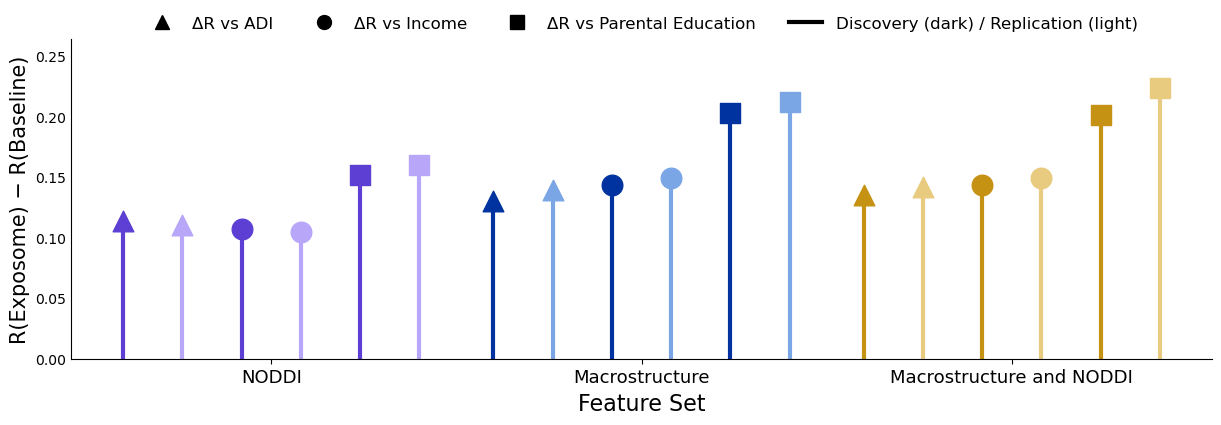

In [23]:
color_disc = {"NODDI": "#5D3FD3", "Macrostructure": "#0033A0", "Macrostructure and NODDI": "#C69214"}
color_repl = {"NODDI": "#B8A6F9", "Macrostructure": "#7BA6E6", "Macrostructure and NODDI": "#E9CB7F"}

order = ["NODDI", "Macrostructure", "Macrostructure and NODDI"]
inc_df_ord = inc_df.set_index("feature_set").loc[order].reset_index()

feature_sets = inc_df_ord["feature_set"].tolist()
disc_inc = inc_df_ord["IncR_General_minus_income_A"].values
repl_inc = inc_df_ord["IncR_General_minus_income_B"].values
disc_ped = inc_df_ord["IncR_General_minus_parentEdu_A"].values
repl_ped = inc_df_ord["IncR_General_minus_parentEdu_B"].values
disc_adi = inc_df_ord["IncR_General_minus_adi_A"].values
repl_adi = inc_df_ord["IncR_General_minus_adi_B"].values

# -------------------- lollipop plot --------------------
fig = plt.figure(figsize=(12.5, 4.8)) 
ax = fig.add_subplot(111)

x = np.arange(len(feature_sets))

width = 0.16
marker_size = 220
stem_lw = 3
bottom_offset = 0.0

for i, fs in enumerate(feature_sets):
    dcol = color_disc[fs]
    rcol = color_repl[fs]

    # ΔR² vs ADI (triangles)
    ax.vlines(x[i]-2.5*width, bottom_offset, disc_adi[i], color=dcol, lw=stem_lw)
    ax.scatter(x[i]-2.5*width, disc_adi[i], color=dcol, marker='^', s=marker_size)

    ax.vlines(x[i]-1.5*width, bottom_offset, repl_adi[i], color=rcol, lw=stem_lw)
    ax.scatter(x[i]-1.5*width, repl_adi[i], color=rcol, marker='^', s=marker_size)

    # ΔR² vs Income (circles)
    ax.vlines(x[i]-0.5*width, bottom_offset, disc_inc[i], color=dcol, lw=stem_lw)
    ax.scatter(x[i]-0.5*width, disc_inc[i], color=dcol, marker='o', s=marker_size)

    ax.vlines(x[i]+0.5*width, bottom_offset, repl_inc[i], color=rcol, lw=stem_lw)
    ax.scatter(x[i]+0.5*width, repl_inc[i], color=rcol, marker='o', s=marker_size)

    # ΔR² vs Parental Education (squares)
    ax.vlines(x[i]+1.5*width, bottom_offset, disc_ped[i], color=dcol, lw=stem_lw)
    ax.scatter(x[i]+1.5*width, disc_ped[i], color=dcol, marker='s', s=marker_size)

    ax.vlines(x[i]+2.5*width, bottom_offset, repl_ped[i], color=rcol, lw=stem_lw)
    ax.scatter(x[i]+2.5*width, repl_ped[i], color=rcol, marker='s', s=marker_size)

ax.set_xticks(x)
ax.set_xticklabels(feature_sets, fontsize=13)
ax.set_xlabel("Feature Set", fontsize=16)
ax.set_ylabel("R(Exposome) − R(Baseline)", fontsize=15)

# y-limits with headroom so top markers don't clip
ymax = max(np.r_[disc_inc, repl_inc, disc_ped, repl_ped, disc_adi, repl_adi])
ax.set_ylim(bottom_offset, ymax + 0.04)

legend_handles = [plt.Line2D([0], [0], color="black", marker='^', lw=0, markersize=10),
                  plt.Line2D([0], [0], color="black", marker='o', lw=0, markersize=10),
                  plt.Line2D([0], [0], color="black", marker='s', lw=0, markersize=10),
                  plt.Line2D([0], [0], color="black", lw=stem_lw)]
ax.legend(legend_handles, ["ΔR vs ADI", "ΔR vs Income", "ΔR vs Parental Education", "Discovery (dark) / Replication (light)"],
          frameon=False, fontsize=12, ncol=4, loc="upper center", bbox_to_anchor=(0.5, 1.12))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color("black")
ax.tick_params(axis="y", length=0)

plt.tight_layout(rect=[0, 0, 1, 0.92])

plt.savefig(SUPPFIG8_DIR / "Figure_IncR2_Lollipop.png", dpi=600, bbox_inches="tight", facecolor="white")
plt.show()

In [27]:
# run permutations and save results 
output_dir = SUPPFIG8_DIR
os.makedirs(f"{output_dir}/perm_results", exist_ok=True)

feature_sets = ["NODDI", "Macrostructure", "Macrostructure and NODDI"]
n_perm = 1000
n_comp = 17
confounds = ['age', 'sex', "t1post_dwi_contrast"]

for fs in feature_sets:
    print(f"Running permutations for: {fs}")
    dfA, dfB = df_map_A[fs], df_map_B[fs]
    features = [c for c in dfA.columns if c.startswith("msmt_")]

    A_train = dfA[dfA["matched_group"] == 1].copy()
    A_test  = dfA[dfA["matched_group"] == 2].copy()
    B_train = dfB[dfB["matched_group"] == 2].copy()
    B_test  = dfB[dfB["matched_group"] == 1].copy()

    # ----------------- A → B direction -----------------
    print("  discovery permutations...")
    X_A_std, y_A_std, X_B_std, y_B_std = rf.prepare_direction_data(A_train, A_test, features, confounds, "General_SES")

    r_true_A, null_A, p_A = rf.permutation_test(X_train=X_A_std, y_train=y_A_std, X_test=X_B_std, y_test=y_B_std,
                                                n_permutations=n_perm, model_type="pls", n_components=n_comp )
    np.savez(f"{output_dir}/perm_results/{fs}_discovery_perm.npz", r_true=r_true_A, null=null_A, p_val=p_A)

    # ----------------- B → A direction -----------------
    print("  replication permutations...")
    X_B2_std,y_B2_std,X_A2_std,y_A2_std = rf.prepare_direction_data(B_train, B_test, features, confounds, "General_SES")

    r_true_B, null_B, p_B = rf.permutation_test(X_train=X_B2_std, y_train=y_B2_std, X_test=X_A2_std, y_test=y_A2_std,
                                                n_permutations=n_perm, model_type="pls", n_components=n_comp)
    np.savez(f"{output_dir}/perm_results/{fs}_replication_perm.npz", r_true=r_true_B, null=null_B, p_val=p_B)

    print(f"  saved {fs} permutation results.")

Running permutations for: NODDI


NameError: name 'df_map_A' is not defined

In [29]:
# same color palettes as scatter/lollipop
color_disc = {"NODDI": "#5D3FD3", "Macrostructure": "#0033A0", "Macrostructure and NODDI": "#C69214"}
color_repl = {"NODDI": "#B8A6F9", "Macrostructure": "#7BA6E6", "Macrostructure and NODDI": "#E9CB7F"}
feature_sets = ["NODDI", "Macrostructure", "Macrostructure and NODDI"]

for fs in feature_sets:
    disc_file = np.load(f"{output_dir}/perm_results/{fs}_discovery_perm.npz") # load discovery
    null_A = disc_file["null"]
    repl_file = np.load(f"{output_dir}/perm_results/{fs}_replication_perm.npz") # load replication
    null_B = repl_file["null"]

    fig = plt.figure(figsize=(3.1, 2.3))
    bins = 20
    sns.histplot(null_B, bins=bins, color=color_repl[fs], edgecolor=None, alpha=0.8)# replication (lighter)
    sns.histplot(null_A, bins=bins, color=color_disc[fs], edgecolor=None, alpha=0.8) # discovery (darker)
    
    plt.gca().yaxis.set_visible(False)
    sns.despine(left=True, right=True, top=True)
    plt.xlabel("r (permuted)", fontsize=20)
    plt.xticks([-0.1, 0, 0.1], fontsize=20)
    plt.tight_layout()
    plt.show()
    fig.savefig(f"{output_dir}/inset_{fs}_combined_NEW.png", dpi=300, facecolor="white")

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig8/perm_results/NODDI_discovery_perm.npz'

In [ ]:
os.makedirs(f"{output_dir}/perm_results_delta", exist_ok=True)

feature_sets = ["NODDI", "Macrostructure", "Macrostructure and NODDI"]
n_perm = 1000
n_comp = 17
confounds = ['age', 'sex', "t1post_dwi_contrast"]

df_map_A_main = df_map_A
df_map_B_main = df_map_B

df_map_A_sens = {"NODDI": dfA_NODDI_sens, "Macrostructure": dfA_macro_sens, "Macrostructure and NODDI": dfA_macro_plus_NODDI_sens}
df_map_B_sens = {"NODDI": dfB_NODDI_sens, "Macrostructure": dfB_macro_sens, "Macrostructure and NODDI": dfB_macro_plus_NODDI_sens}

# Helpers
def fit_predict_pls(X_train, y_train, X_test, n_comp):
    pls = PLSRegression(n_components=n_comp)
    pls.fit(X_train, y_train)
    return pls.predict(X_test).ravel()

def r_and_r2(y_true, y_pred):
    r = np.corrcoef(y_true, y_pred)[0, 1]
    return r, r**2

def align_by_subject(df_main, df_sens, id_col="subject_id_clean"):
    """
    Return aligned copies of main and sens dfs restricted to common subjects.
    Preserves order of df_main.
    """
    common = df_main[id_col].isin(df_sens[id_col])
    df_main_aligned = df_main.loc[common].copy()
    df_sens_aligned = df_sens.set_index(id_col).loc[df_main_aligned[id_col]].reset_index()
    return df_main_aligned, df_sens_aligned

def prepare_direction(df_train, df_test, features, confounds, target):
    return rf.prepare_direction_data(df_train, df_test, features, confounds, target)

def delta_perm_test(dfA_main, dfB_main, dfA_sens, dfB_sens, features, baseline_target,
                    n_perm=1000, n_comp=17):

    # ---- Split main and sens separately ----
    A_train_main = dfA_main[dfA_main["matched_group"] == 1].copy()
    A_test_main  = dfA_main[dfA_main["matched_group"] == 2].copy()
    B_train_main = dfB_main[dfB_main["matched_group"] == 2].copy()
    B_test_main  = dfB_main[dfB_main["matched_group"] == 1].copy()

    A_train_sens = dfA_sens[dfA_sens["matched_group"] == 1].copy()
    A_test_sens  = dfA_sens[dfA_sens["matched_group"] == 2].copy()
    B_train_sens = dfB_sens[dfB_sens["matched_group"] == 2].copy()
    B_test_sens  = dfB_sens[dfB_sens["matched_group"] == 1].copy()

    # ===================================================
    # A -> B (discovery): align TRAIN and TEST separately
    # ===================================================
    A_train_main, A_train_sens = align_by_subject(A_train_main, A_train_sens)
    A_test_main,  A_test_sens  = align_by_subject(A_test_main,  A_test_sens)

    # prepare data
    X_A, yA_gen, X_B, yB_gen = prepare_direction(A_train_main, A_test_main, features, confounds, "General_SES")
    _,  yA_base, _,  yB_base = prepare_direction(A_train_sens, A_test_sens, features, confounds, baseline_target)

    # observed
    pred_gen  = fit_predict_pls(X_A, yA_gen,  X_B, n_comp)
    pred_base = fit_predict_pls(X_A, yA_base, X_B, n_comp)

    _, r2_gen  = r_and_r2(yB_gen,  pred_gen)
    _, r2_base = r_and_r2(yB_base, pred_base)
    delta_obs_A = r2_gen - r2_base

    # permutation null (permute TRAIN labels with same perm for both targets)
    null_delta_A = np.zeros(n_perm)
    n_train = len(yA_gen)
    for p in range(n_perm):
        perm_idx = np.random.permutation(n_train)
        yA_gen_p  = yA_gen[perm_idx]
        yA_base_p = yA_base[perm_idx]

        pred_gen_p  = fit_predict_pls(X_A, yA_gen_p,  X_B, n_comp)
        pred_base_p = fit_predict_pls(X_A, yA_base_p, X_B, n_comp)

        _, r2_gen_p  = r_and_r2(yB_gen,  pred_gen_p)
        _, r2_base_p = r_and_r2(yB_base, pred_base_p)
        null_delta_A[p] = r2_gen_p - r2_base_p

    pval_A = (np.sum(null_delta_A >= delta_obs_A) + 1) / (n_perm + 1)

    # ===================================================
    # B -> A (replication): align TRAIN and TEST separately
    # ===================================================
    B_train_main, B_train_sens = align_by_subject(B_train_main, B_train_sens)
    B_test_main,  B_test_sens  = align_by_subject(B_test_main,  B_test_sens)

    X_B2, yB_gen2, X_A2, yA_gen2 = prepare_direction(B_train_main, B_test_main, features, confounds, "General_SES")
    _,   yB_base2, _,   yA_base2 = prepare_direction(B_train_sens, B_test_sens, features, confounds, baseline_target)

    pred_gen2  = fit_predict_pls(X_B2, yB_gen2,  X_A2, n_comp)
    pred_base2 = fit_predict_pls(X_B2, yB_base2, X_A2, n_comp)

    _, r2_gen2  = r_and_r2(yA_gen2,  pred_gen2)
    _, r2_base2 = r_and_r2(yA_base2, pred_base2)
    delta_obs_B = r2_gen2 - r2_base2

    null_delta_B = np.zeros(n_perm)
    n_train2 = len(yB_gen2)
    for p in range(n_perm):
        perm_idx = np.random.permutation(n_train2)
        yB_gen_p2  = yB_gen2[perm_idx]
        yB_base_p2 = yB_base2[perm_idx]

        pred_gen_p2  = fit_predict_pls(X_B2, yB_gen_p2,  X_A2, n_comp)
        pred_base_p2 = fit_predict_pls(X_B2, yB_base_p2, X_A2, n_comp)

        _, r2_gen_p2  = r_and_r2(yA_gen2,  pred_gen_p2)
        _, r2_base_p2 = r_and_r2(yA_base2, pred_base_p2)
        null_delta_B[p] = r2_gen_p2 - r2_base_p2

    pval_B = (np.sum(null_delta_B >= delta_obs_B) + 1) / (n_perm + 1)

    return {
        "delta_obs_A": delta_obs_A, "null_A": null_delta_A, "p_A": pval_A,
        "delta_obs_B": delta_obs_B, "null_B": null_delta_B, "p_B": pval_B,
        "r2_gen_A": r2_gen, "r2_base_A": r2_base,
        "r2_gen_B": r2_gen2, "r2_base_B": r2_base2
    }

# -------------------------------------------------------
# Run for both baselines and all feature sets
# -------------------------------------------------------
all_out = []

for fs in feature_sets:
    print(f"\n=== ΔR² permutation tests for feature set: {fs} ===")

    dfA_main = df_map_A_main[fs]
    dfB_main = df_map_B_main[fs]
    dfA_sens = df_map_A_sens[fs]
    dfB_sens = df_map_B_sens[fs]

    features = [c for c in dfA_main.columns if c.startswith("msmt_")]

    for baseline in ["income", "parental_education"]:
        print(f"  baseline = {baseline}")

        out = delta_perm_test(
            dfA_main, dfB_main, dfA_sens, dfB_sens,
            features, baseline_target=baseline,
            n_perm=n_perm, n_comp=n_comp
        )

        np.savez(
            f"{output_dir}/perm_results_delta/{fs}_{baseline}_delta_perm.npz",
            delta_obs_A=out["delta_obs_A"], null_A=out["null_A"], p_A=out["p_A"],
            delta_obs_B=out["delta_obs_B"], null_B=out["null_B"], p_B=out["p_B"]
        )

        all_out.append({
            "feature_set": fs,
            "baseline": baseline,
            "R2_General_A": out["r2_gen_A"],
            f"R2_{baseline}_A": out["r2_base_A"],
            "DeltaR2_A": out["delta_obs_A"],
            "p_A": out["p_A"],
            "R2_General_B": out["r2_gen_B"],
            f"R2_{baseline}_B": out["r2_base_B"],
            "DeltaR2_B": out["delta_obs_B"],
            "p_B": out["p_B"],
        })

        print(f"    ΔR²_A={out['delta_obs_A']:.3f}, p_A={out['p_A']:.4f}")
        print(f"    ΔR²_B={out['delta_obs_B']:.3f}, p_B={out['p_B']:.4f}")

delta_summary = pd.DataFrame(all_out)
print("\n=== SUMMARY: ΔR²(General_SES - baseline) with permutation p-values ===")
print(delta_summary.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
delta_summary